# Rate Allocator: demo interactivo

## Bancos y SOFIPOs en México

Aquí el ahorro del día a día suele ir a un banco conocido o a una SOFIPO. Las SOFIPOs incluyen buena parte de las apps de ahorro que la gente trae en el celular. No es lo mismo: el seguro de depósitos (hasta dónde te cubren si algo truena) y cómo te cobran impuestos sobre el interés cambian de producto a producto.

La tasa también depende del monto. Lo que anuncian en grande muchas veces vale solo para la primera porción del saldo; lo demás cae a otra tasa. Además, bancos y SOFIPOs mueven promociones y topes seguido, así que lo que lucía mejor el mes pasado no siempre aguanta hoy.

Este cuaderno es un ensayo chico. Pones un total en pesos, marcas qué instituciones cuentan, y te propone una forma de repartir el dinero para que la cuenta favorezca el rendimiento modelado, con cifras de práctica que vienen en el proyecto (no son cotizaciones de ventanilla). Cuando cambien tus tasas o techos, mete los números nuevos y vuelve a correrlo.

Los supuestos de impuestos y seguro para México viven junto al resto del material de ejemplo en la carpeta `data` del proyecto.

## Qué hace esta herramienta

Escribes pesos, eliges instituciones y el cuaderno sugiere cuánto dejar en cada una con las tasas del demo. Las tablas de abajo leen los mismos datos de práctica. No es asesoría legal, fiscal, bancaria ni de seguros. Revisa lo que publiquen tus proveedores y platica con alguien calificado si vas en serio.

## Cómo usar este cuaderno

1. En el menú, ejecuta todas las celdas de arriba abajo la primera vez (en la mayoría está en Run / Ejecutar). Igual si la pantalla se trabó.
2. Cuando salga el panel, marca o desmarca cada banco o SOFIPO que quieras en el ejercicio.
3. Mueve el deslizador o usa la caja numérica y los + / − para el total, en pasos de 100 pesos.
4. Baja: la tabla y los gráficos se redibujan cuando cambias algo arriba.
5. Si la salida se ve vacía o duplicada, vuelve a ejecutar todo desde el inicio.


## Inicio rápido

Abre el cuaderno y ejecuta todas las celdas de arriba abajo una vez para que carguen los pasos. Los primeros bloques traen los bancos y tasas de ejemplo.


In [1]:
%matplotlib agg
# Non-interactive backend; charts are embedded as PNG inside updatable HTML (no results Output widget).

import os

from ipywidgets import VBox, HBox, Button, FloatSlider, BoundedFloatText, Checkbox, HTML, Layout
from IPython.display import display, clear_output
from traitlets import link as traitlets_link

from rate_allocator import allocate, build_interactive_report_html
from rate_allocator.adapters.yaml_loader import load_institutions_with_overrides

if os.path.basename(os.getcwd()) == 'notebooks':
    data_file = '../data/sample1.yaml'
else:
    data_file = 'data/sample1.yaml'

base_institutions = load_institutions_with_overrides(data_file, {})
print(f"Cargadas {len(base_institutions)} instituciones desde {data_file}")
print("demo_ipywidgets_es UI versión: 7 (deslizador + BoundedFloatText ±100 botones, enlace traitlets).")


Cargadas 5 instituciones desde ../data/sample1.yaml
demo_ipywidgets_es UI versión: 7 (deslizador + BoundedFloatText ±100 botones, enlace traitlets).


## Tus controles

Corre las celdas de abajo de este título hasta ver las casillas de instituciones y la fila del monto (deslizador más caja numérica).


In [2]:
%load_ext autoreload
%autoreload 2


In [3]:
def _brief_constraints_label(inst):
    parts = []
    for tier in inst.tiers:
        for c in tier.constraints:
            parts.append(f"{c.type} ${c.cost:.2f}")

    return ", ".join(parts) if parts else "sin comisiones modeladas"


_TOTAL_MIN = 0
_TOTAL_MAX = 1_200_000
_TOTAL_DEFAULT = 100_000

allocation_slider = FloatSlider(
    value=_TOTAL_DEFAULT,
    min=_TOTAL_MIN,
    max=_TOTAL_MAX,
    step=1000,
    description='Total (MXN):',
    continuous_update=False,
    readout_format=".0f",
    layout=Layout(width="100%"),
)

allocation_amount = BoundedFloatText(
    value=float(_TOTAL_DEFAULT),
    min=float(_TOTAL_MIN),
    max=float(_TOTAL_MAX),
    step=100,
    description='Total (escribe o ±100):',
    layout=Layout(flex="1"),
)


def _snap_total(v: float) -> float:
    v = round(v / 100) * 100
    return float(max(_TOTAL_MIN, min(_TOTAL_MAX, v)))


def _bump_total(delta: float) -> None:
    allocation_amount.value = _snap_total(allocation_amount.value + delta)


minus_100 = Button(description="−", tooltip="Restar 100 MXN", layout=Layout(width="40px"))
plus_100 = Button(description="+", tooltip="Sumar 100 MXN", layout=Layout(width="40px"))
minus_100.on_click(lambda _b: _bump_total(-100))
plus_100.on_click(lambda _b: _bump_total(100))

allocation_amount_row = HBox(
    [minus_100, allocation_amount, plus_100],
    layout=Layout(width="100%"),
)

_total_value_link = traitlets_link((allocation_slider, "value"), (allocation_amount, "value"))

institution_checkboxes = {}
for inst in base_institutions:
    hint = _brief_constraints_label(inst)
    cb_label = inst.name if hint == "sin comisiones modeladas" else f"{inst.name} ({hint})"
    institution_checkboxes[inst.name] = Checkbox(
        value=True,
        description=cb_label,
        indent=False,
        layout=Layout(width="100%"),
    )

footnote = HTML(
    '<small>Usa cada casilla de <b>Institución</b> para incluir o excluir ese proveedor de la optimización.\nEl texto entre paréntesis resume comisiones o condiciones del YAML (el optimizador las aplica si la institución está incluida).\nEl <em>rendimiento esperado</em> destacado usa el horizonte seleccionado con compuesto bruto menos comisiones de horizonte, incluida ISR estimada sobre interés real (con el proxy de inflación).\nLa retención bancaria se informa por separado como flujo de caja y no se resta del rendimiento neto de la optimización.\nEl gráfico inferior usa la misma asignación con capitalización tipo diaria (m=365) frente a devengo simple.</small>'
)

control_panel = VBox(
    [
        HTML('<b>Instituciones</b>'),
        *institution_checkboxes.values(),
        footnote,
        allocation_slider,
        allocation_amount_row,
    ],
    layout=Layout(max_width="720px"),
)

display(control_panel)


## Qué verás a continuación

Debajo de la siguiente celda de código salen una tabla y gráficos ligados a lo que marcaste arriba.


### Tabla y gráficos

La siguiente celda dibuja la tabla y las figuras. Cambias casilla o monto y se actualizan.

Si se ve vacío o repetido, ejecuta otra vez todas las celdas desde el principio.


Institución,Tramo,Principal,Tasa nominal,Rendimiento bruto (compuesto),"Comisiones (restricciones + impuesto, horizonte)",Rendimiento neto nominal,Rendimiento neto real
Nu,1,"$25,000",13.00%,"$3,470.05",[1] $12.00,"$3,458.05","$2,405.55"
OpenBank,1,"$40,000",13.00%,"$5,552.08",ISR $34.81,"$5,517.27","$3,833.27"
PlataAhorroPlus,1,"$35,000",12.00%,"$4,461.61","[2] $1,378.08 + ISR $26.89","$3,056.64","$1,583.14"

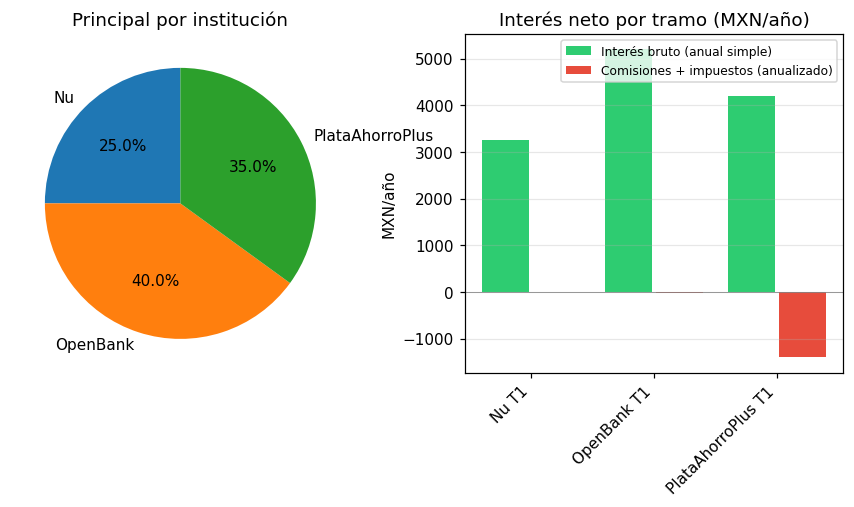
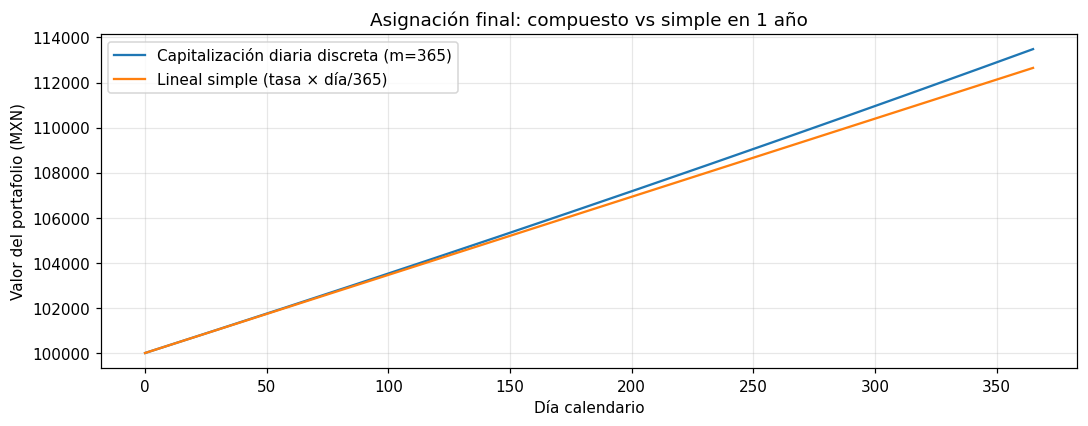

/Users/gera.ledesma/Desktop/Projects/rate-allocator/src/rate_allocator/workflows/interactive_report.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


In [4]:
import time
from IPython.display import clear_output, display, HTML

# One cell for results + wiring: clear this cell's outputs first (stops stacked HTML/widgets after reopen + Run All).
clear_output(wait=True)

RESULTS_DISPLAY_ID = f"rate-allocator-results-{time.time_ns()}"
display(HTML("<b>Resultados de asignación</b>"))
alloc_results_handle = display(
    HTML("<p><i>Cargando...</i></p>"),
    display_id=RESULTS_DISPLAY_ID,
)


def _push_results_html(fragment: str):
    alloc_results_handle.update(HTML(fragment))


def build_selected_institutions():
    return [name for name, checkbox in institution_checkboxes.items() if checkbox.value]


def run_allocation(_=None):
    selected_names = build_selected_institutions()

    if not selected_names:
        _push_results_html('<p>Selecciona al menos una institución.</p>')
        return

    all_institutions = load_institutions_with_overrides(data_file, {})
    institutions = [inst for inst in all_institutions if inst.name in selected_names]

    total = allocation_slider.value
    horizon_years = 1.0
    result = allocate(
        total=total,
        institutions=institutions,
        horizon_years=horizon_years,
        periods_per_year=365,
    )

    html_fragment = build_interactive_report_html(
        result,
        institutions,
        total=total,
        horizon_years=horizon_years,
        periods_per_year=365,
        locale="es",
    )
    _push_results_html(html_fragment)


for checkbox in institution_checkboxes.values():
    checkbox.unobserve_all(name="value")
allocation_slider.unobserve_all(name="value")

for checkbox in institution_checkboxes.values():
    checkbox.observe(run_allocation, names="value")
allocation_slider.observe(run_allocation, names="value")

run_allocation()


## Notas


In [5]:
print(
    "Las casillas incluyen o excluyen cada proveedor de la optimización "
    "(las comisiones y condiciones del YAML siguen aplicando si está incluida la institución; las comisiones incluyen ISR estimada sobre interés real, y la retención se muestra aparte)."
)


Las casillas incluyen o excluyen cada proveedor de la optimización (las comisiones y condiciones del YAML siguen aplicando si está incluida la institución; las comisiones incluyen ISR estimada sobre interés real, y la retención se muestra aparte).


Las tablas restan cargos tipo comisión según las reglas de ejemplo de cada institución más una ISR estimada sobre interés real en el horizonte que uses (notas al pie y columnas de comisiones).

El rendimiento neto va en columnas nominal y real. La retención bancaria aparece aparte como algo tipo flujo de efectivo; no va metida en la misma línea de neto que resalta la optimización.

---

## Aviso regulatorio (México)

Los números de impuestos y seguro en los informes usan supuestos por defecto del archivo de parámetros regulatorios (México) en la carpeta `data` del proyecto (país MX, vigencia desde 2026-01-01). Solo como orientación: depósitos bancarios ~$3,300,000 MXN por depositante por banco bajo IPAB (400,000 UDIS en ese archivo); depósitos en SOFIPO ~$208,000 MXN bajo Prosofipo (25,000 UDIS). El bosquejo fiscal incluye retención anual del 0.9% sobre intereses, ISR anual estimado del 0.9% sobre interés real, un proxy de inflación del 4.21% anual y en SOFIPO saldo exento ~$213,973 MXN (5 UMA en ese archivo) con ISR del 0.9% sobre el excedente. Los productos reales cambian por fecha y contrato. Este demo no certifica cobertura IPAB ni Prosofipo ni define tus impuestos. Confirma con tu institución y con un profesional antes de actuar.
